In [ ]:
!pip install -q transformers datasets accelerate scikit-learn torchvision

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
train = pd.read_csv("dataset_train.csv")
test  = pd.read_csv("dataset_test.csv")
print("Latih:", len(train), "| Uji:", len(test))

Saving dataset_test.csv to dataset_test.csv
Saving dataset_train.csv to dataset_train.csv
Latih: 3476 | Uji: 869


In [ ]:
label2id = {"negatif": 0, "netral": 1, "positif": 2}
id2label = {v: k for k, v in label2id.items()}

train["label_id"] = train["label"].map(label2id)
test["label_id"]  = test["label"].map(label2id)

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

# Hapus data dengan normalized_text yang kosong
train = train.dropna(subset=["normalized_text"]).copy()
test = test.dropna(subset=["normalized_text"]).copy()

def to_dataset(df):
    d = df[["normalized_text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True)
    return Dataset.from_pandas(d)

train_ds = to_dataset(train)
test_ds  = to_dataset(test)

def tokenize(batch):
    return tokenizer(
        batch["normalized_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True).remove_columns(["normalized_text"])
test_ds  = test_ds.map(tokenize, batched=True).remove_columns(["normalized_text"])
train_ds.set_format("torch")
test_ds.set_format("torch")

Map:   0%|          | 0/3475 [00:00<?, ? examples/s]

Map:   0%|          | 0/869 [00:00<?, ? examples/s]

In [ ]:
import numpy as np, torch
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight("balanced", classes=np.array([0,1,2]), y=train["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)
print("Bobot kelas:", class_weights)

Bobot kelas: tensor([ 0.3824, 10.7253,  3.4270])


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL, num_labels=3, id2label=id2label, label2id=label2id
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import TrainingArguments, Trainer

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_precision": p, "macro_recall": r, "macro_f1": f1}

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

args = TrainingArguments(
    output_dir="indobert_output",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.910474,0.922902,0.777906,0.487448,0.564605,0.490159
2,0.764404,0.947706,0.836594,0.507605,0.576061,0.532304
3,0.583488,1.249545,0.866513,0.565514,0.558198,0.554019
4,0.265833,1.589531,0.887227,0.599751,0.564104,0.579638


TrainOutput(global_step=872, training_loss=0.5753757554456729, metrics={'train_runtime': 320.2917, 'train_samples_per_second': 43.398, 'train_steps_per_second': 2.723, 'total_flos': 914319126604800.0, 'train_loss': 0.5753757554456729, 'epoch': 4.0})

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(-1)
y_true = pred.label_ids

print(classification_report(y_true, y_pred, target_names=["negatif","netral","positif"], digits=4))
print("Confusion Matrix (urutan: negatif, netral, positif):")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

     negatif     0.9351    0.9524    0.9437       757
      netral     0.3000    0.2222    0.2553        27
     positif     0.5641    0.5176    0.5399        85

    accuracy                         0.8872       869
   macro avg     0.5998    0.5641    0.5796       869
weighted avg     0.8791    0.8872    0.8828       869

Confusion Matrix (urutan: negatif, netral, positif):
[[721   8  28]
 [ 15   6   6]
 [ 35   6  44]]


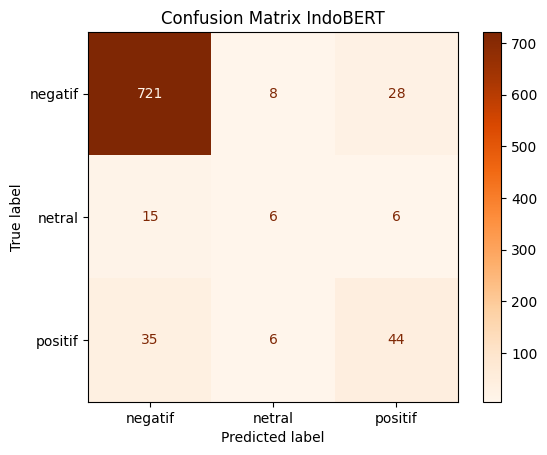

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=["negatif","netral","positif"],
    cmap="Oranges"
)
plt.title("Confusion Matrix IndoBERT")
plt.show()